This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - always picking 5 tasks. 

In [54]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# start with some U_true, in this simulation its 5 tasks x 5 parcels

In [55]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [56]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [57]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

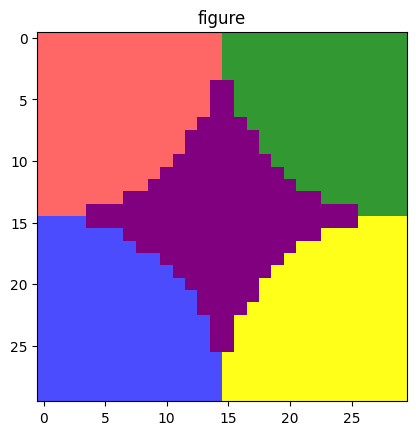

In [58]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

In [59]:
if type(U_true_5) == pt.Tensor:
    U_true_5 = U_true_5.numpy()

print(type(U_true_5))

if U_true_5.ndim == 2:
    U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])

print(U_true_5.shape)

<class 'numpy.ndarray'>
(1, 5, 900)


# Make a random task battery with 30 task and plot second moment matrix

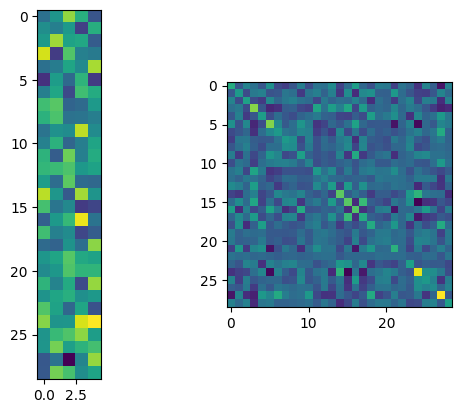

In [60]:
num_task_lib = 29
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

In [61]:
Y_true = V_lib @ np.array(U_true_5[0])
vtest = V_lib
ytest = Y_true


In [100]:
# try and evaluate random combinations of these task 
noise = 1

D = ut.build_combinations(G_lib, strategy='random', n_iter=10000, n_tasks=6, seed=2, replacement=True)
# Try the classification of the region voxels
D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, V_lib, U_true_5, sig_e=noise, vtest=vtest, ytest=ytest)
#reset indices of D_ev
D_ev = D_ev.reset_index(drop=True)

In [107]:
num_batteries = 2500
num_iterations = 1000
eval_metric = 'perc'
output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)



In [108]:
std = (output_df['variance'] - output_df['variance_mc']).std()

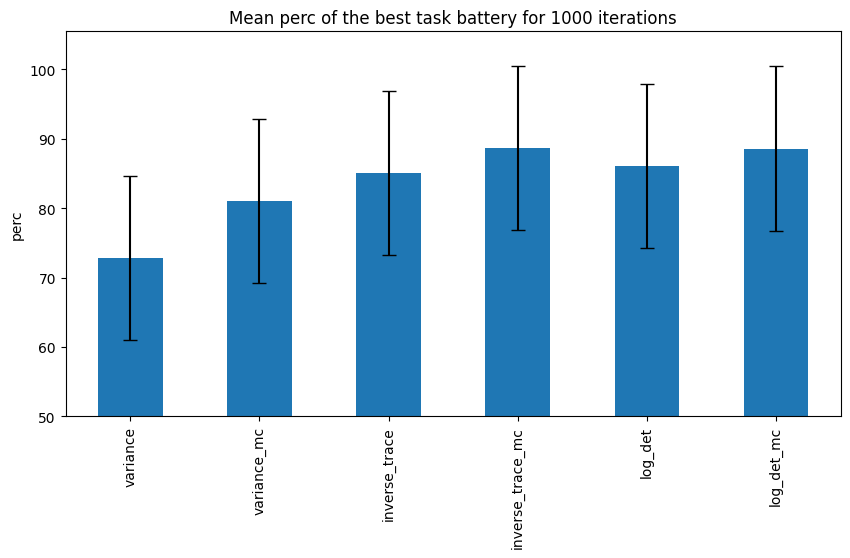

In [109]:
# plot the means as a bar plot
fig, ax = plt.subplots(figsize=(10, 5))
output_df.mean().plot(kind='bar', ax=ax, yerr=std, capsize=5)
# set minimum y value to 50
ax.set_ylim(bottom=50)
ax.set_ylabel(eval_metric)
ax.set_title(f'Mean {eval_metric} of the best task battery for {num_iterations} iterations')
plt.show()


In [49]:
D_ev_var = D_ev.sort_values(by='variance', ascending=False).reset_index(drop=True)
D_ev_var_mc = D_ev.sort_values(by='variance_mc', ascending=False).reset_index(drop=True)
cos_differences = D_ev_var['perc'] - D_ev_var_mc['perc']

cos_diff_std = np.std(cos_differences, ddof=1)

# Does the usefullness of the eigenmetrics change with changing the number of tasks?

In [34]:
# 2 to 24 steps of 2
battery_sizes = [4,8,14,18,22]
noise = 1

In [35]:
results_list = []

for i in battery_sizes:
    noise = 1 * np.sqrt(i)
    print(f"Processing battery size: {i}")
    
    # Generate task combinations and evaluate
    D = ut.build_combinations(G_lib, strategy='random', n_iter=5000, n_tasks=i, seed=2, replacement=True)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, V_lib, U_true_5, sig_e=noise, vtest=vtest, ytest=ytest)
    D_ev = D_ev.reset_index(drop=True)
    
    # Perform max value distribution analysis
    num_batteries = 500
    num_iterations = 1000
    eval_metric = 'perc'
    output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)
    output_long = output_df.melt(var_name="metric", value_name="value")
    
    output_long["battery_size"] = i
    
    results_list.append(output_long)

results_df = pd.concat(results_list, ignore_index=True)

Processing battery size: 4
Processing battery size: 8
Processing battery size: 14
Processing battery size: 18
Processing battery size: 22


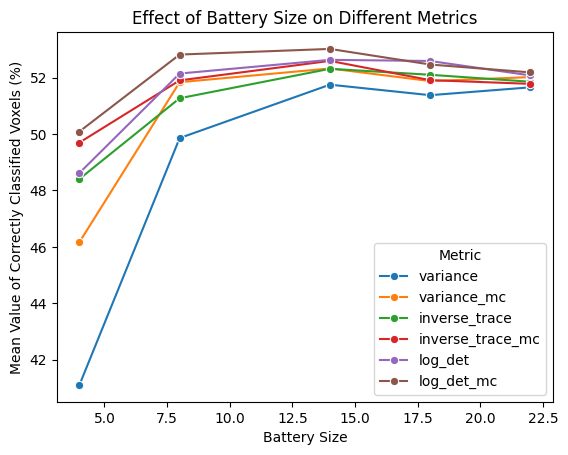

In [36]:
agg_df = results_df.groupby(["battery_size", "metric"], as_index=False).agg(
    mean_value=("value", "mean")
)

palette = sns.color_palette("tab10", n_colors=agg_df["metric"].nunique())

sns.lineplot(
    data=results_df,
    x="battery_size",
    y="value",
    hue="metric",
    marker="o",
    palette=palette,
    errorbar=None 
)

plt.xlabel("Battery Size")
plt.ylabel("Mean Value of Correctly Classified Voxels (%)")
plt.title("Effect of Battery Size on Different Metrics")
plt.legend(title="Metric")

plt.show()



# Next are the results dataset specific? if we generate many Vs from which the data will come from. Are the results the same?

In [37]:
num_iter = 100
num_task_lib = 29

In [20]:
results_list = []
metrics = ['variance','log_det','inverse_trace','variance_mc','log_det_mc','inverse_trace_mc']

for i in range(num_iter): 
    if i % 1 == 0:
        print(f"Processing iteration: {i}")
    
    rng = np.random.default_rng(seed=i)
    V_lib = rng.normal(0,1,(num_task_lib, K_main))
    V_lib = V_lib - V_lib.mean(axis=0, keepdims=True) 
    G_lib = V_lib @ V_lib.T

    Y_true = V_lib @ np.array(U_true_5[0])
    vtest = V_lib
    ytest = Y_true

    D = ut.build_combinations(G_lib, strategy='random', n_iter=1000, n_tasks=6, seed=2, replacement=True)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, V_lib, U_true_5, sig_e=noise, vtest=vtest, ytest=ytest)
    D_ev = D_ev.reset_index(drop=True)

    for metric in metrics:
        max_metric_row = D_ev.loc[D_ev[metric].idxmax()]
        results_list.append({
            "iteration": i,
            "metric": metric,
            "perc_value": max_metric_row["perc"]
        })

results_df = pd.DataFrame(results_list)

Processing iteration: 0
Processing iteration: 1
Processing iteration: 2
Processing iteration: 3
Processing iteration: 4
Processing iteration: 5
Processing iteration: 6
Processing iteration: 7
Processing iteration: 8
Processing iteration: 9
Processing iteration: 10
Processing iteration: 11
Processing iteration: 12
Processing iteration: 13
Processing iteration: 14
Processing iteration: 15
Processing iteration: 16
Processing iteration: 17
Processing iteration: 18
Processing iteration: 19
Processing iteration: 20
Processing iteration: 21
Processing iteration: 22
Processing iteration: 23
Processing iteration: 24
Processing iteration: 25
Processing iteration: 26
Processing iteration: 27
Processing iteration: 28
Processing iteration: 29
Processing iteration: 30
Processing iteration: 31
Processing iteration: 32
Processing iteration: 33
Processing iteration: 34
Processing iteration: 35
Processing iteration: 36
Processing iteration: 37
Processing iteration: 38
Processing iteration: 39
Processing

C:\Users\barafat\AppData\Local\Temp\ipykernel_4856\2897474034.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


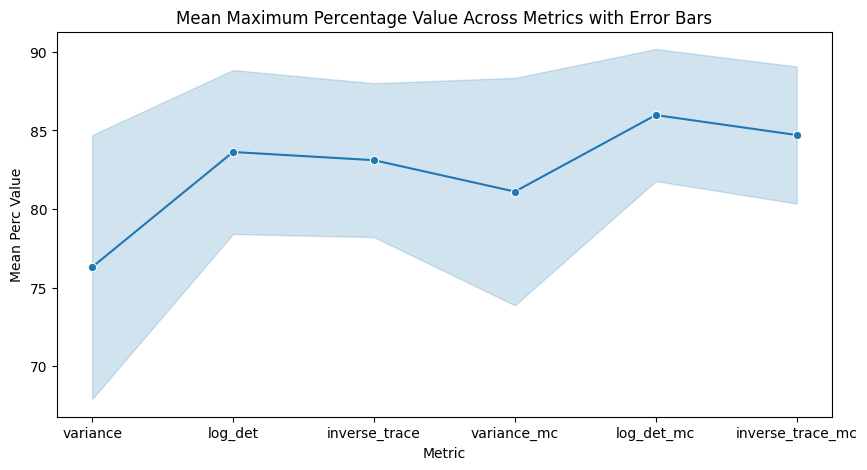

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="metric",      
    y="perc_value",   
    errorbar="sd",    
    marker="o",
    palette="tab10"
)

plt.xlabel("Metric")
plt.ylabel("Mean Perc Value")
plt.title("Mean Maximum Percentage Value Across Metrics with Error Bars")

plt.show()
